In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import io
df2 = pd.read_csv('Mall_Customer.csv')

In [ ]:
df2.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,2,5,21,47
1,2,1,5,59,3
2,3,2,3,32,10
3,4,2,1,64,54
4,5,2,1,26,50


In [ ]:
df2.shape

(8993, 5)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8993 entries, 0 to 8992
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              8993 non-null   int64
 1   Gender                  8993 non-null   int64
 2   Age                     8993 non-null   int64
 3   Annual Income (k$)      8993 non-null   int64
 4   Spending Score (1-100)  8993 non-null   int64
dtypes: int64(5)
memory usage: 351.4 KB


In [ ]:
df2.describe()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,8993.000000,8993.000000,8993.000000,8993.000000,8993.000000
mean,4497.000000,1.546870,3.415212,55.544312,50.604915
std,2596.199819,0.497826,1.637581,26.340913,28.681768
min,1.000000,1.000000,1.000000,10.000000,1.000000
25%,2249.000000,1.000000,2.000000,33.000000,26.000000
50%,4497.000000,2.000000,3.000000,56.000000,51.000000
75%,6745.000000,2.000000,4.000000,79.000000,76.000000
max,8993.000000,2.000000,7.000000,100.000000,100.000000


In [ ]:
df2.isnull().values.any()

False

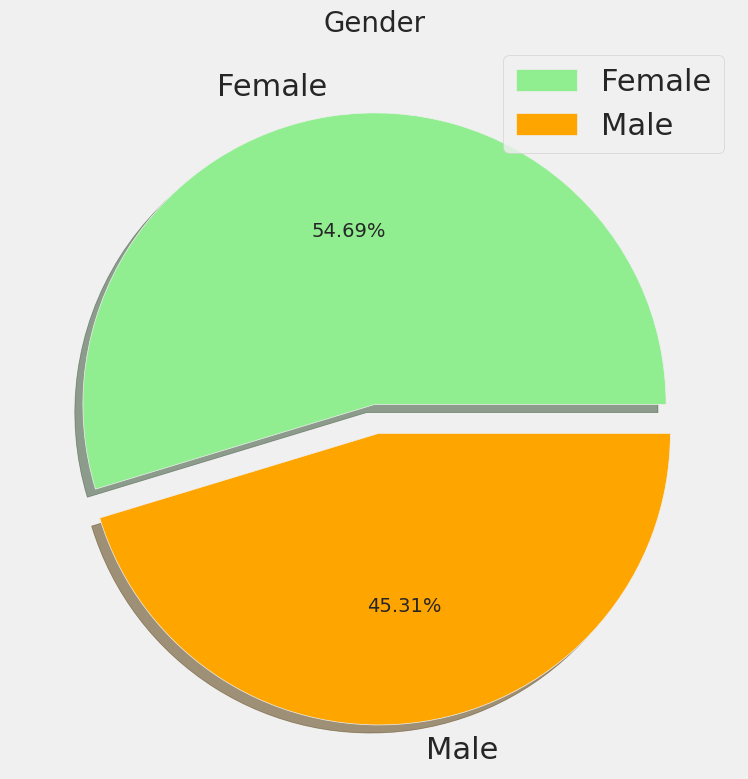

In [ ]:
labels = ['Female', 'Male']
size = df2['Gender'].value_counts()
colors = ['lightgreen', 'orange']
explode = [0, 0.1]
plt.rcParams['figure.figsize'] = (9, 9)
plt.pie(size, colors = colors, explode = explode, labels = labels, shadow = True, autopct = '%.2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')
plt.legend()
plt.show()

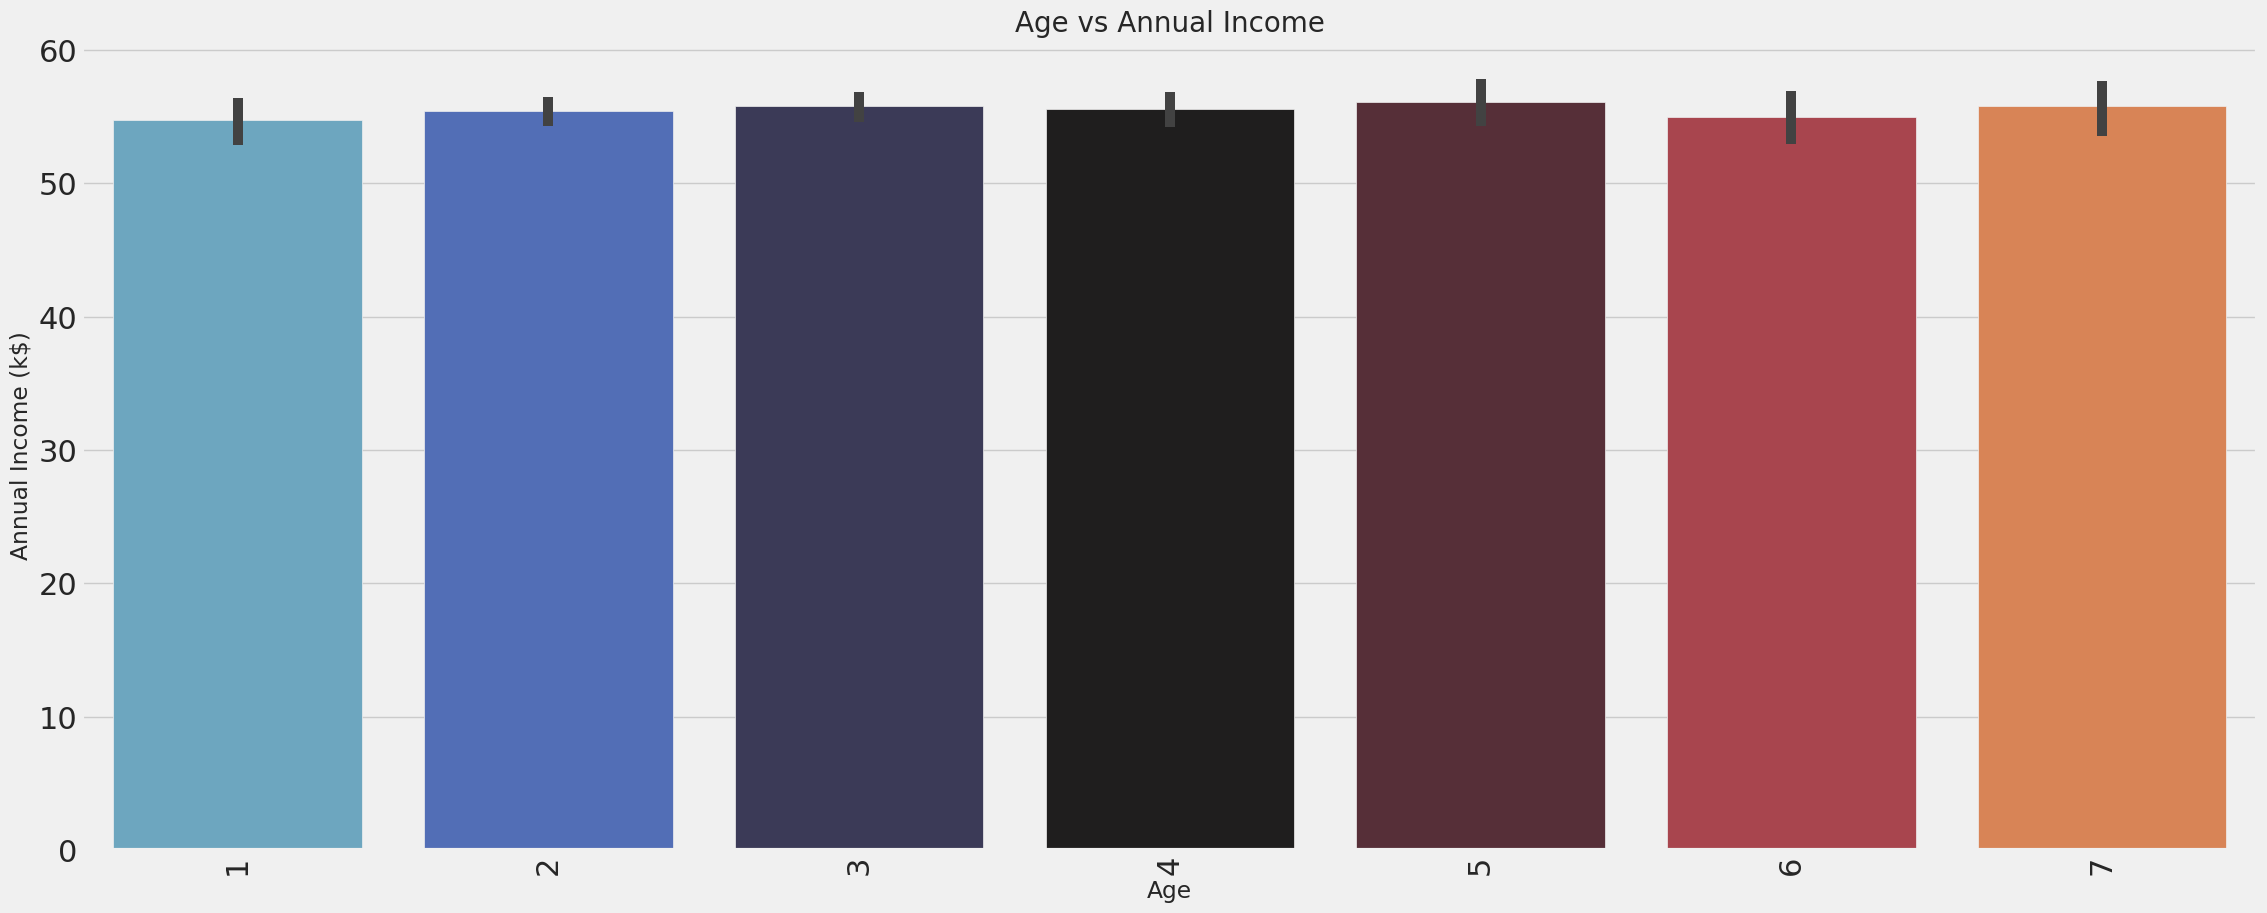

In [ ]:
plt.figure(figsize=(25,10))
# Passing X axis and Y axis along with subplot position
plt.title('Age vs Annual Income', fontsize = 20)
plt.xticks(rotation=90)
sns.barplot(x = df2['Age'] , y = df2['Annual Income (k$)'] , palette='icefire');

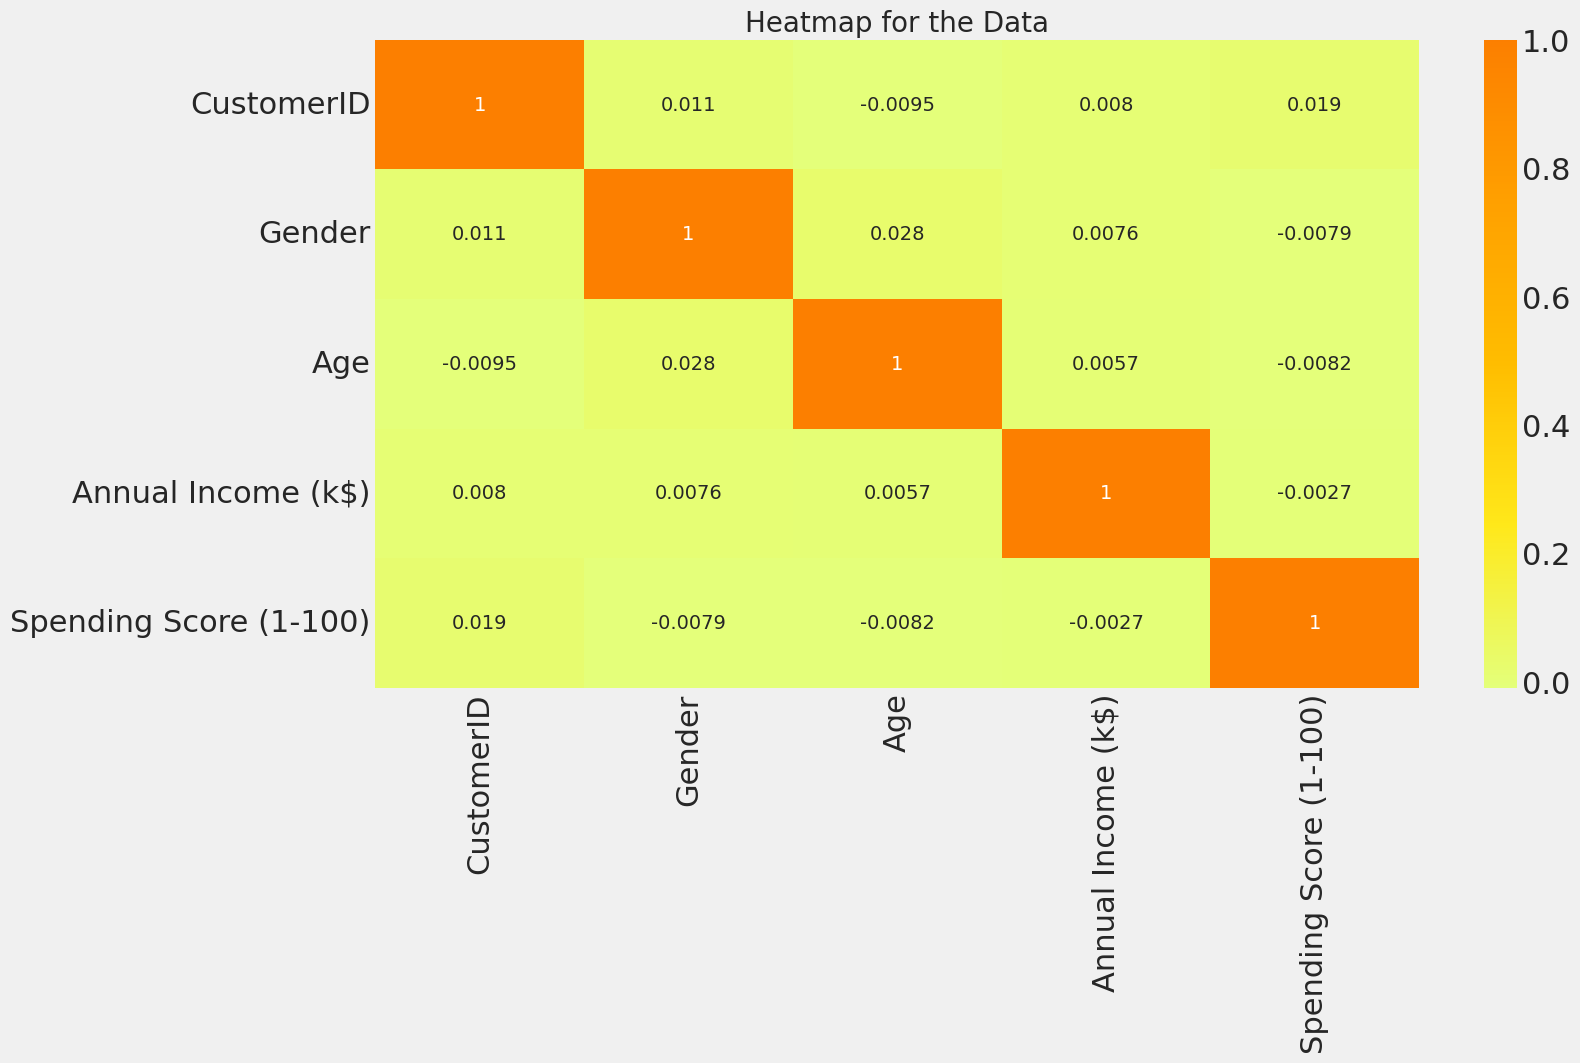

In [ ]:
plt.rcParams['figure.figsize'] = (15, 8)
sns.heatmap(df2.corr(), cmap = 'Wistia', annot = True)
plt.title('Heatmap for the Data', fontsize = 20)
plt.show()

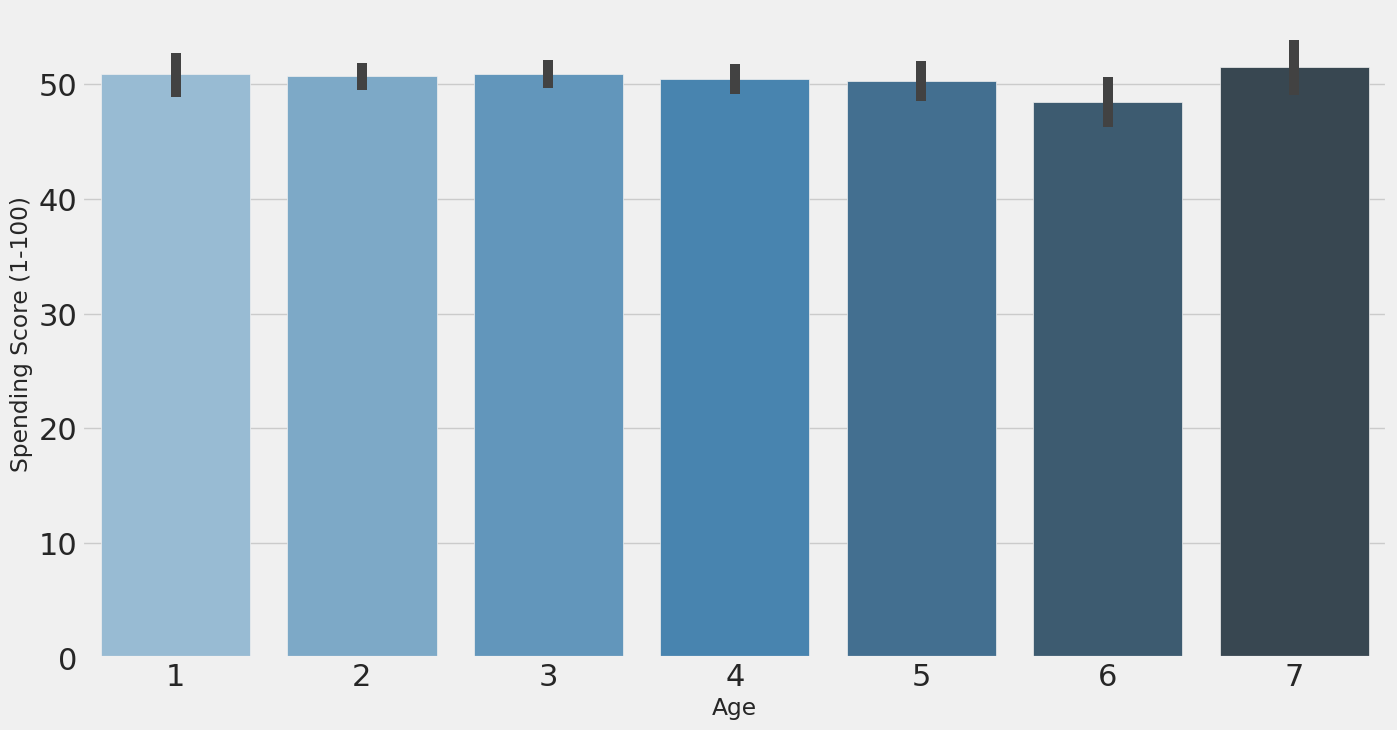

In [ ]:
ax = sns.barplot(y= "Spending Score (1-100)", x = "Age", data = df2, palette=("Blues_d"))
sns.set(rc={'figure.figsize':(27.7,6.30)})
sns.set_context("poster")

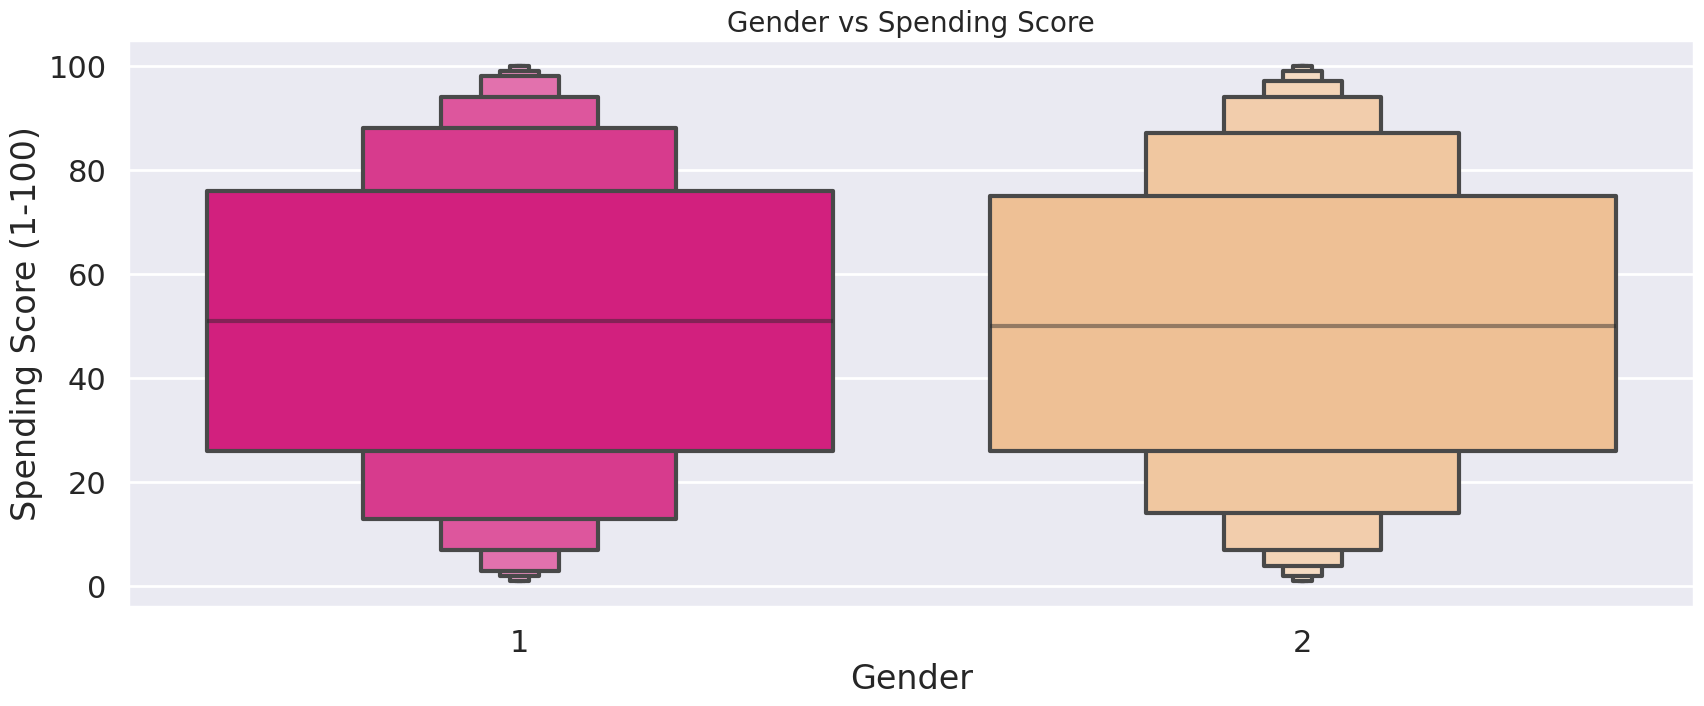

In [ ]:
plt.rcParams['figure.figsize'] = (18, 7)
sns.boxenplot(x='Gender', y='Spending Score (1-100)', data=df2, palette='Accent_r')
plt.title('Gender vs Spending Score', fontsize=20)
plt.show()


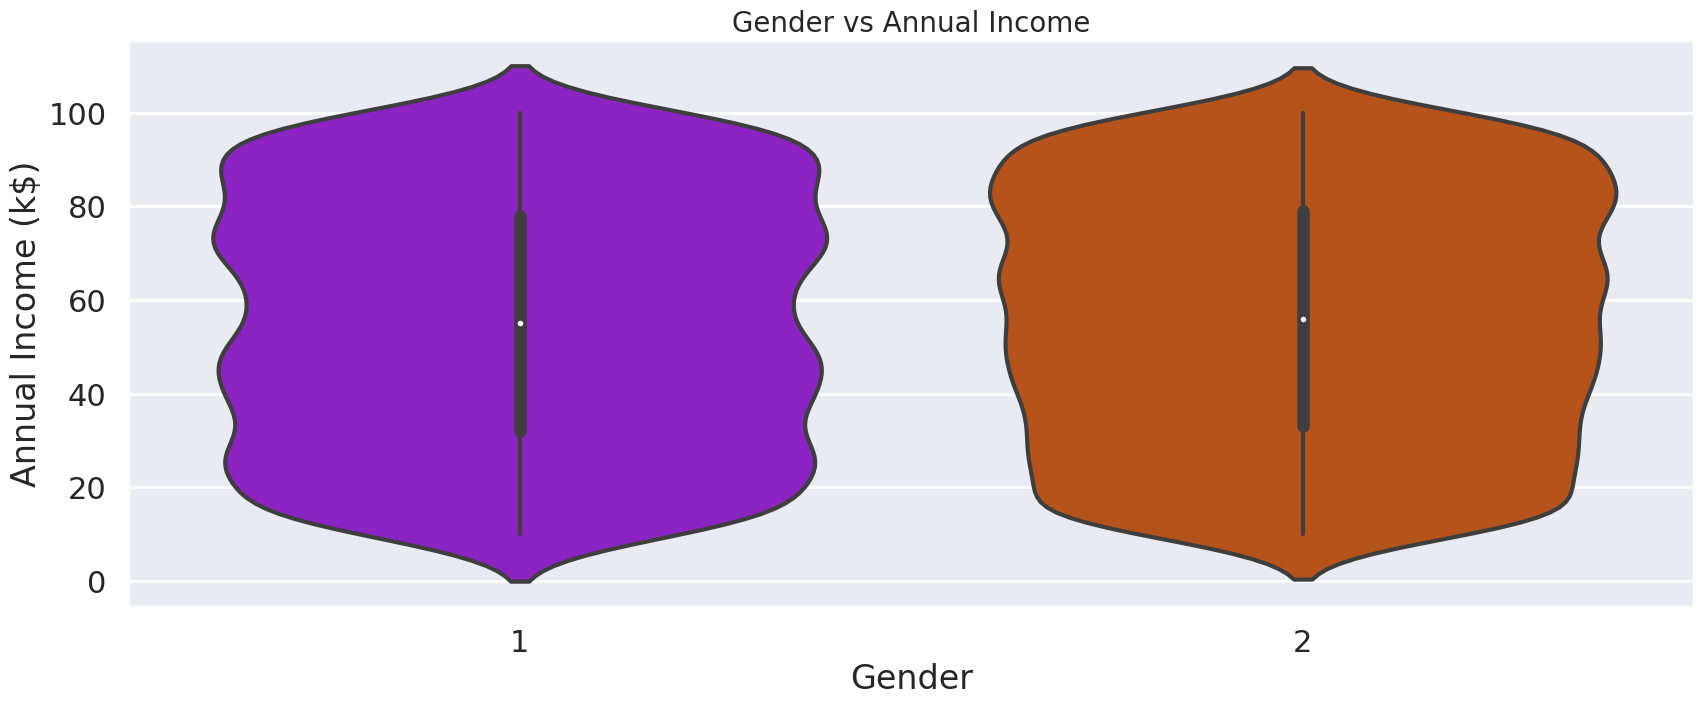

In [ ]:
plt.rcParams['figure.figsize'] = (18, 7)
sns.violinplot(x='Gender', y='Annual Income (k$)', data=df2, palette='gnuplot')
plt.title('Gender vs Annual Income', fontsize=20)
plt.show()


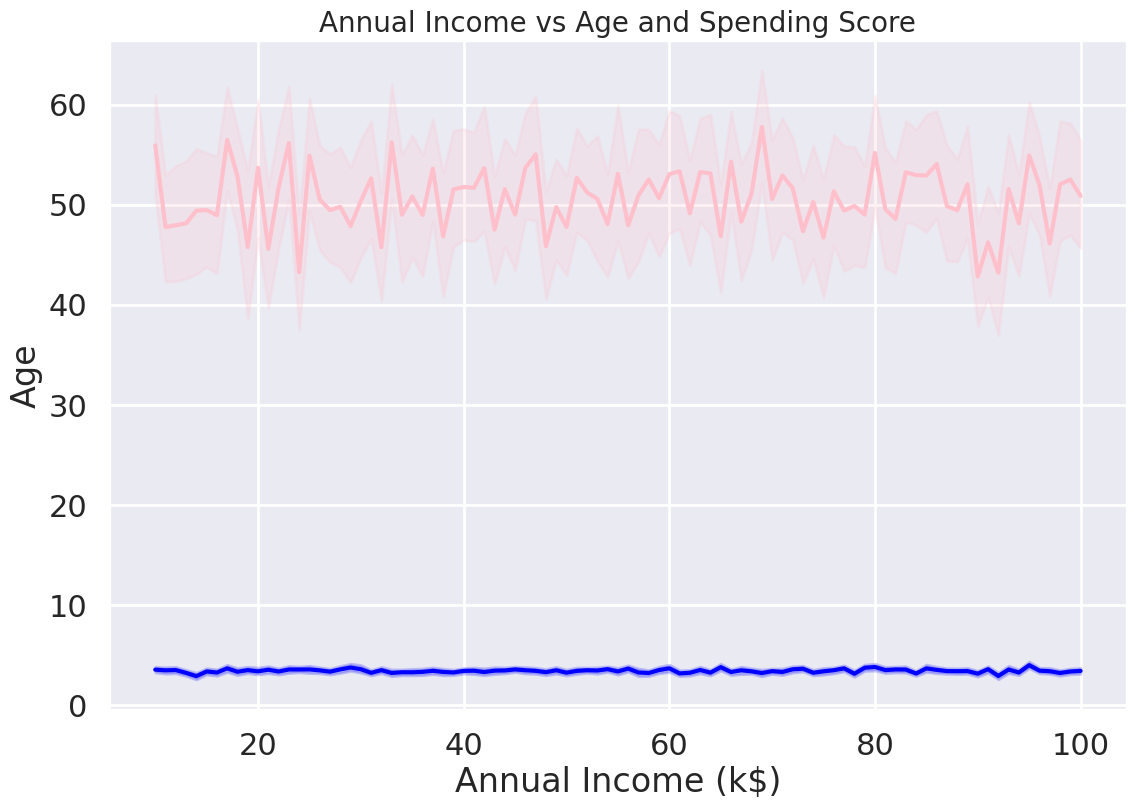

In [ ]:
x = df2['Annual Income (k$)']
y = df2['Age']
z = df2['Spending Score (1-100)']
sns.lineplot(x=x, y=y, color='blue', palette='Accent_r', data=df2)
sns.lineplot(x=x, y=z, color='pink', palette='Accent_r', data=df2)
plt.title('Annual Income vs Age and Spending Score', fontsize=20)
plt.show()


### **k - Means Clustering**

In [ ]:
x = df2.iloc[:, [3, 4]].values

In [ ]:
print(x.shape)

(8993, 2)


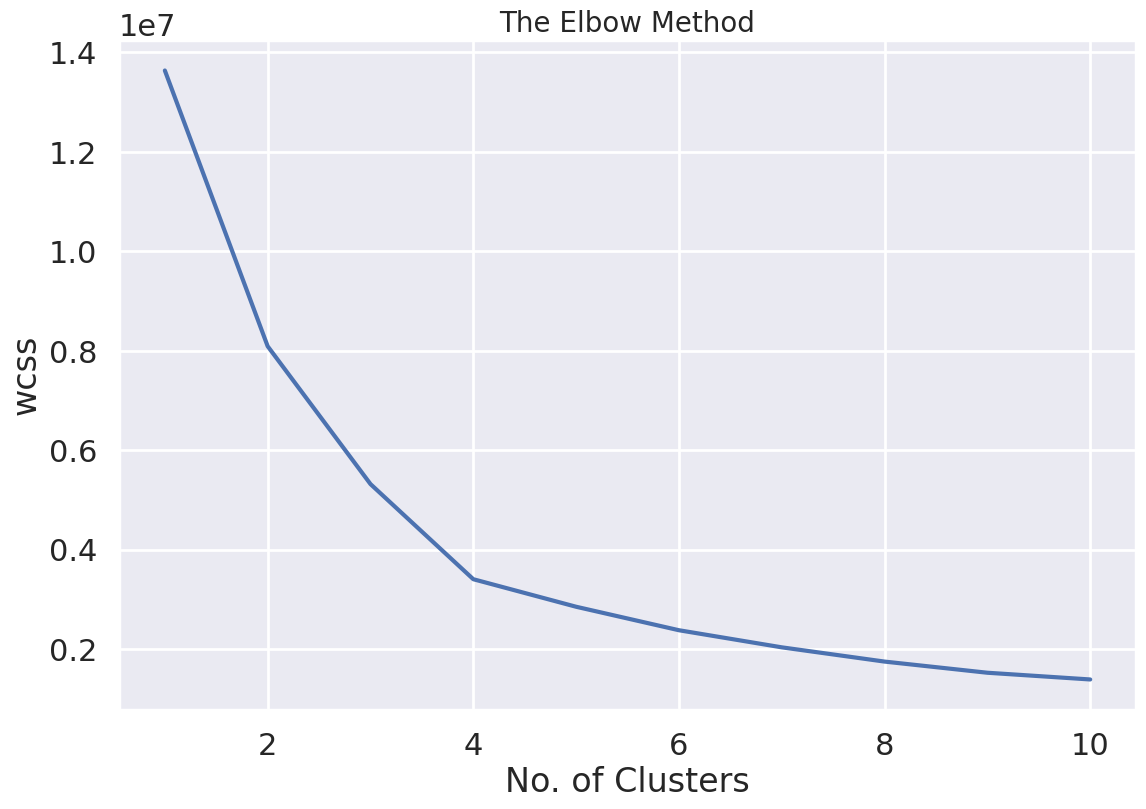

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
  km.fit(x)
  wcss.append(km.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_means = km.fit_predict(x)

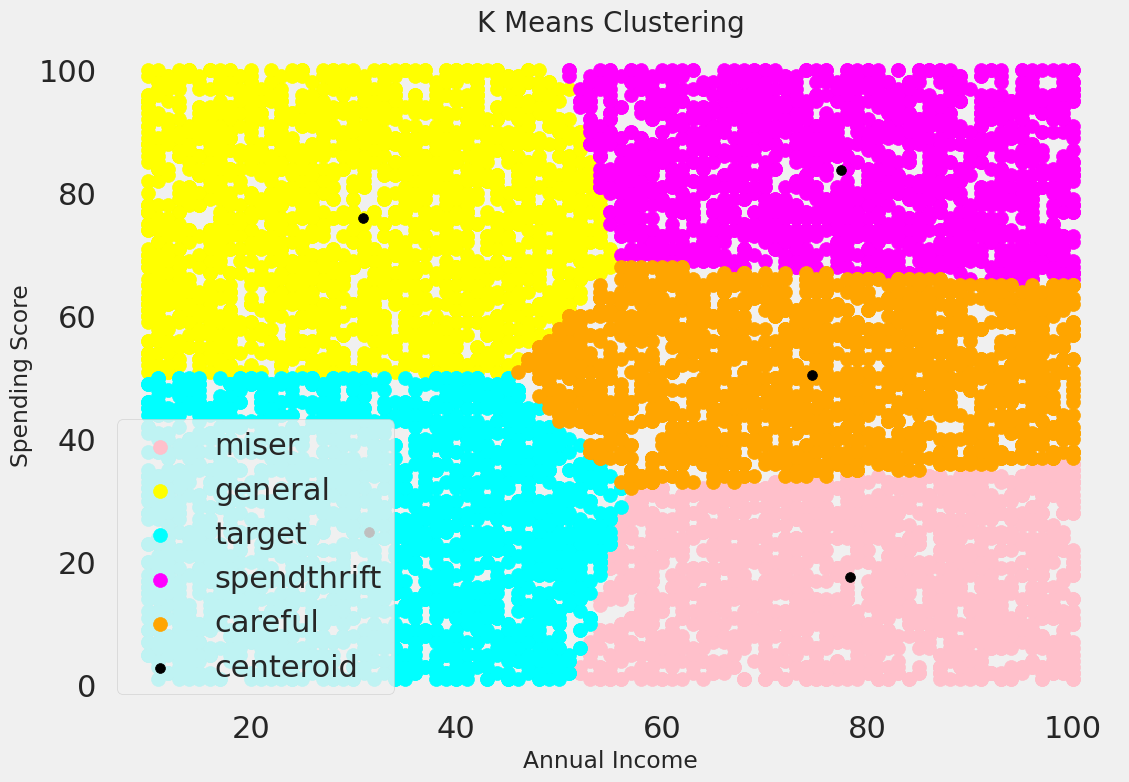

In [ ]:
plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 100, c = 'pink', label = 'miser')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 100, c = 'yellow', label = 'general')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s = 100, c = 'cyan', label = 'target')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s = 100, c = 'magenta', label = 'spendthrift')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s = 100, c = 'orange', label = 'careful')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'black' , label = 'centeroid')
plt.style.use('fivethirtyeight')
plt.title('K Means Clustering', fontsize = 20)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()

### **Hierarchical Clustering**

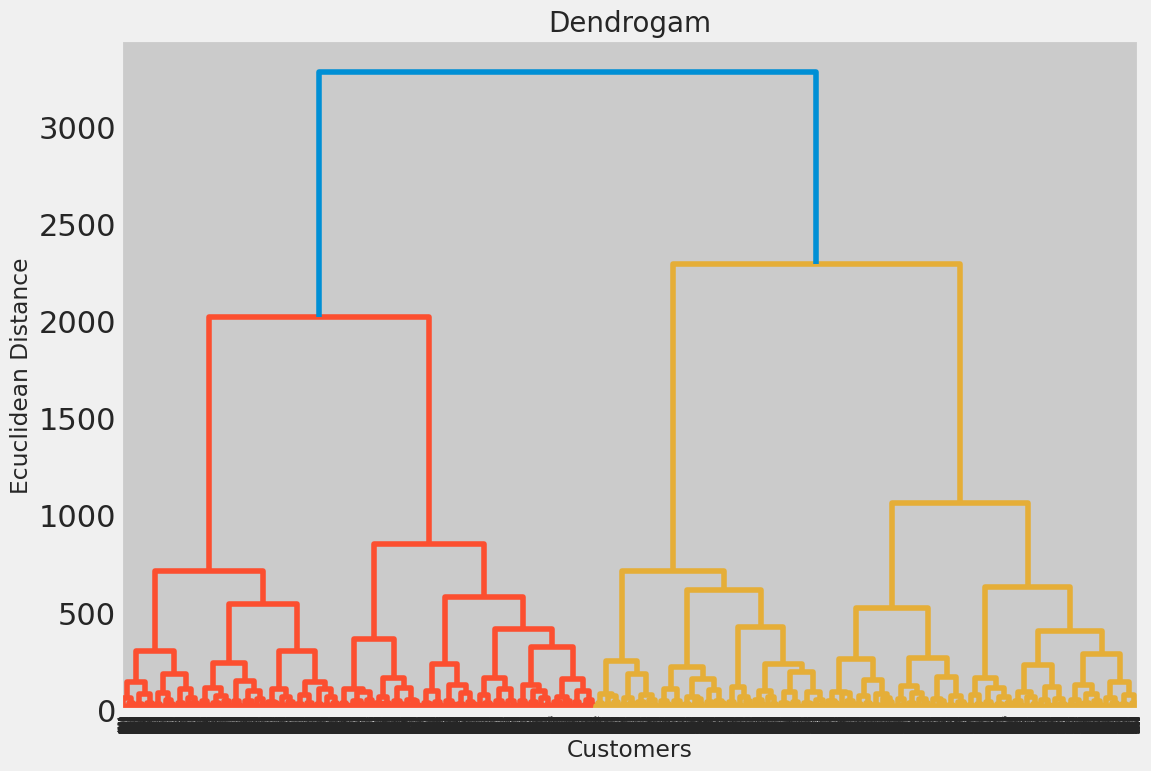

In [ ]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(x, method = 'ward'))
plt.title('Dendrogam', fontsize = 20)
plt.xlabel('Customers')
plt.ylabel('Ecuclidean Distance')
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(x)

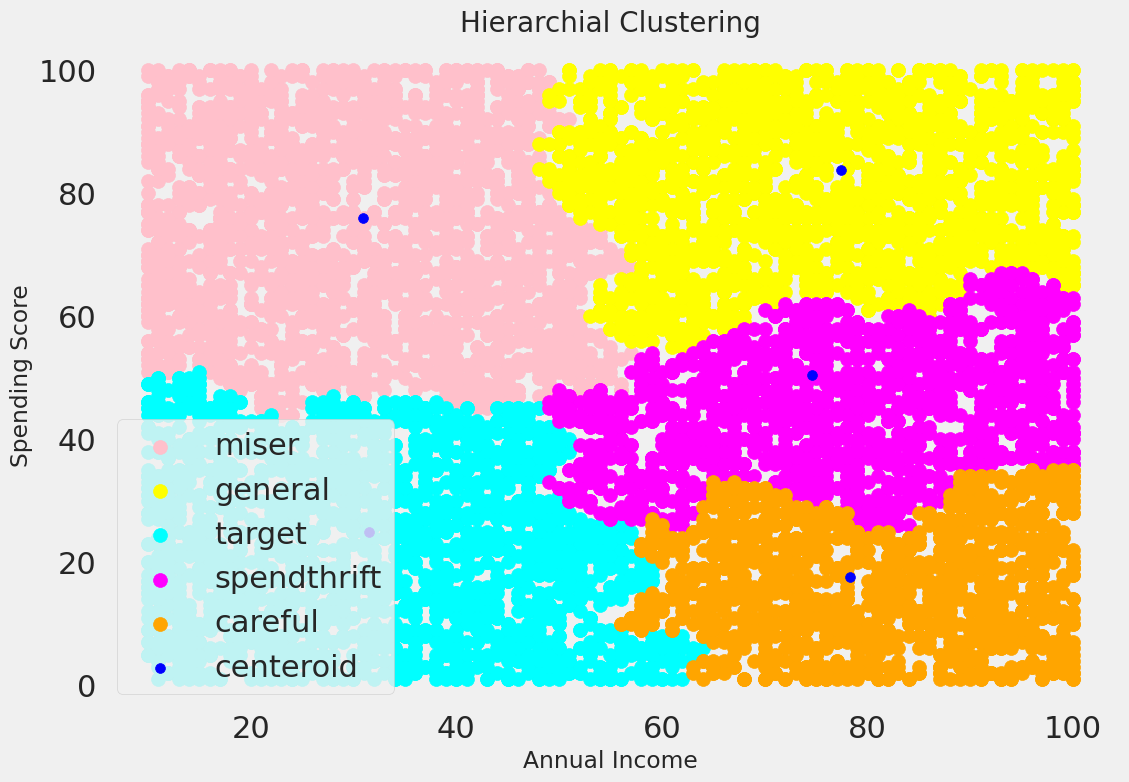

In [ ]:
plt.scatter(x[y_hc == 0, 0], x[y_hc == 0, 1], s = 100, c = 'pink', label = 'miser')
plt.scatter(x[y_hc == 1, 0], x[y_hc == 1, 1], s = 100, c = 'yellow', label = 'general')
plt.scatter(x[y_hc == 2, 0], x[y_hc == 2, 1], s = 100, c = 'cyan', label = 'target')
plt.scatter(x[y_hc == 3, 0], x[y_hc == 3, 1], s = 100, c = 'magenta', label = 'spendthrift')
plt.scatter(x[y_hc == 4, 0], x[y_hc == 4, 1], s = 100, c = 'orange', label = 'careful')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'blue' , label = 'centeroid')
plt.style.use('fivethirtyeight')
plt.title('Hierarchial Clustering', fontsize = 20)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()


### **ACCURACY FOR BOTH K MEANS AND HIERARCHICAL CLUSTERING**

K-means silhouette score: 0.9999999984375548
Hierarchical clustering silhouette score: 0.669965527182134


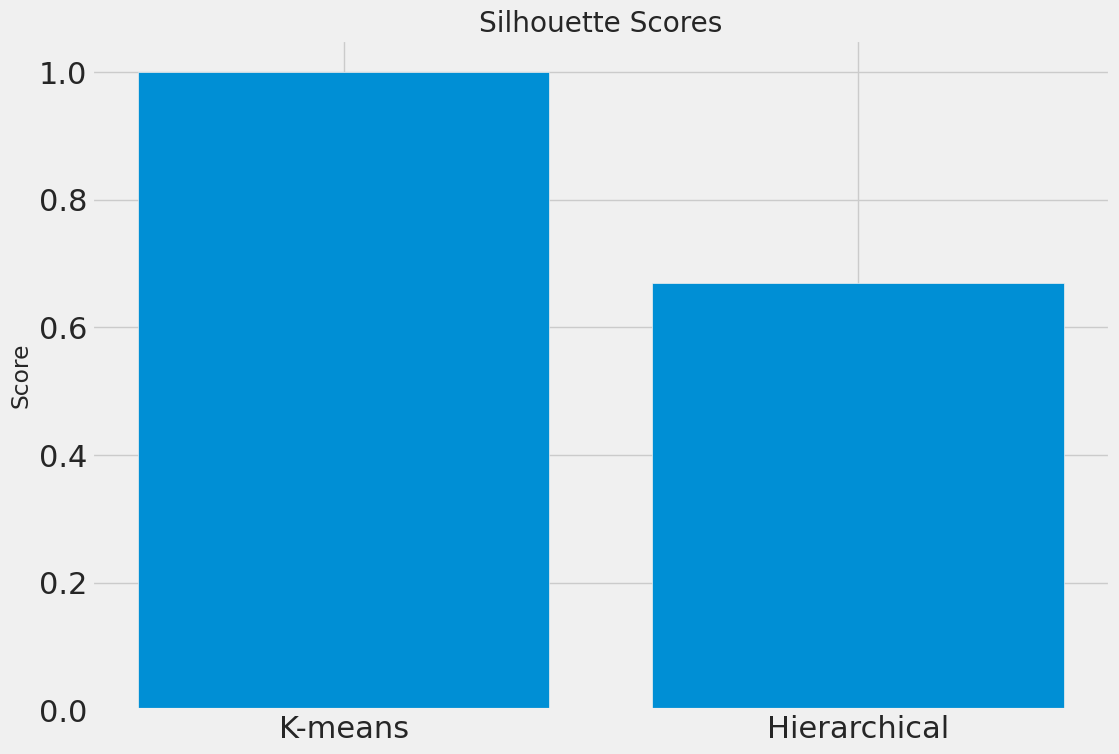

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Preprocess the data
scaler = StandardScaler()
data = scaler.fit_transform(df.iloc[:, [3,4]])

# Apply k-means clustering
kmeans = KMeans(n_clusters = 200)
kmeans.fit(data)
kmeans_labels = kmeans.labels_
kmeans_silhouette = silhouette_score(data, kmeans_labels)

# Apply hierarchical clustering
agg = AgglomerativeClustering(n_clusters = 200)
agg.fit(data)
agg_labels = agg.labels_
agg_silhouette = silhouette_score(data, agg_labels)

# Evaluate the results
print("K-means silhouette score:", kmeans_silhouette)
print("Hierarchical clustering silhouette score:", agg_silhouette)

# Plot the results
labels = ["K-means", "Hierarchical"]
silhouette_scores = [kmeans_silhouette, agg_silhouette]
plt.bar(labels, silhouette_scores)
plt.title("Silhouette Scores")
plt.ylabel("Score")
plt.show()